In [46]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras
from keras import layers

In [47]:
IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 100
EPOCHS = 50
CLASSES = 2

In [48]:
# 1. Dataset Loading
(ds_train, ds_test), ds_info = tfds.load("cats_vs_dogs", split=["train[:90%]", "train[90%:]"], shuffle_files=True, as_supervised=True, with_info=True) #

def preprocess_image(image, label):
    # Resize to 64x64
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    # Normalize to [-1, 1]
    image = (image - 127.5) / 127.5
    # Ensure label is integer
    label = tf.cast(label, tf.int32)
    return image, label

# 2. Preprocessing Pipeline
train_dataset = ds_train.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = ds_test.map(preprocess_image).batch(BATCH_SIZE)

In [49]:
def build_generator(latent_dim, num_classes):
    # Inputs: Noise vector and Label
    target_label = layers.Input(shape=(1,), name="label_input")
    noise = layers.Input(shape=(latent_dim,), name="noise_input")

    # Label embedding: Map label to a vector space
    label_embedding = layers.Embedding(num_classes, latent_dim)(target_label)
    label_embedding = layers.Flatten()(label_embedding)

    # Combine noise and label
    combined_input = layers.Multiply()([noise, label_embedding])

    # Foundation for 4x4 image
    x = layers.Dense(4 * 4 * 512, use_bias=False)(combined_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((4, 4, 512))(x)

    # Upsampling to 8x8, 16x16, 32x32, then 64x64
    x = layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final output layer: 64x64x3 with tanh activation
    out = layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding="same", activation="tanh")(x)

    return keras.Model([noise, target_label], out, name="generator")

generator = build_generator(LATENT_DIM, CLASSES)

In [50]:
def build_discriminator(img_shape, num_classes):
    # Inputs: Image and Label
    img_input = layers.Input(shape=img_shape, name="image_input")
    label_input = layers.Input(shape=(1,), name="label_input")

    # Embed label and reshape to match image dimensions for concatenation
    label_embedding = layers.Embedding(num_classes, 64 * 64)(label_input)
    label_embedding = layers.Reshape((64, 64, 1))(label_embedding)

    # Concatenate label channel to image
    combined_input = layers.Concatenate()([img_input, label_embedding])

    # Downsample: 64x64 -> 32x32 -> 16x16 -> 8x8
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding="same")(combined_input)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)

    # Final Classification
    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model([img_input, label_input], out, name="discriminator")

discriminator = build_discriminator(img_shape=(64, 64, 3), num_classes=2)

In [51]:
cross_entropy = keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

gen_optimizer = keras.optimizers.legacy.Adam(1e-4, beta_1=0.5)
disc_optimizer = keras.optimizers.legacy.Adam(1e-4, beta_1=0.5)

In [52]:

@tf.function
def train_step(images, labels):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Generate fake images conditioned on labels
        generated_images = generator([noise, labels], training=True)

        # 2. Get discriminator outputs for real and fake images
        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        # 3. Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 4. Apply gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

# Training Loop
for epoch in range(EPOCHS):
    for image_batch, label_batch in train_dataset:
        # Adjust batch size for last batch if necessary
        if image_batch.shape[0] == BATCH_SIZE:
            g_loss, d_loss = train_step(image_batch, label_batch)
            
    print(f"Epoch {epoch+1}: Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")

Epoch 1: Gen Loss: 0.7289, Disc Loss: 1.3667
Epoch 2: Gen Loss: 0.7634, Disc Loss: 1.3248
Epoch 3: Gen Loss: 0.7254, Disc Loss: 1.4471
Epoch 4: Gen Loss: 0.6970, Disc Loss: 1.2992
Epoch 5: Gen Loss: 0.8119, Disc Loss: 1.1391
Epoch 6: Gen Loss: 0.7862, Disc Loss: 1.2881
Epoch 7: Gen Loss: 0.7930, Disc Loss: 1.5340
Epoch 8: Gen Loss: 0.8148, Disc Loss: 1.2109
Epoch 9: Gen Loss: 0.7644, Disc Loss: 1.2294
Epoch 10: Gen Loss: 0.7153, Disc Loss: 1.7245
Epoch 11: Gen Loss: 0.7221, Disc Loss: 1.4018
Epoch 12: Gen Loss: 0.7228, Disc Loss: 1.5755
Epoch 13: Gen Loss: 0.6993, Disc Loss: 1.3762
Epoch 14: Gen Loss: 0.6904, Disc Loss: 1.4144
Epoch 15: Gen Loss: 0.6820, Disc Loss: 1.4030
Epoch 16: Gen Loss: 0.7043, Disc Loss: 1.3533
Epoch 17: Gen Loss: 0.7115, Disc Loss: 1.4053
Epoch 18: Gen Loss: 0.6395, Disc Loss: 1.3775
Epoch 19: Gen Loss: 0.6829, Disc Loss: 1.3890
Epoch 20: Gen Loss: 0.7005, Disc Loss: 1.3897
Epoch 21: Gen Loss: 0.6726, Disc Loss: 1.4245
Epoch 22: Gen Loss: 0.8229, Disc Loss: 1.25

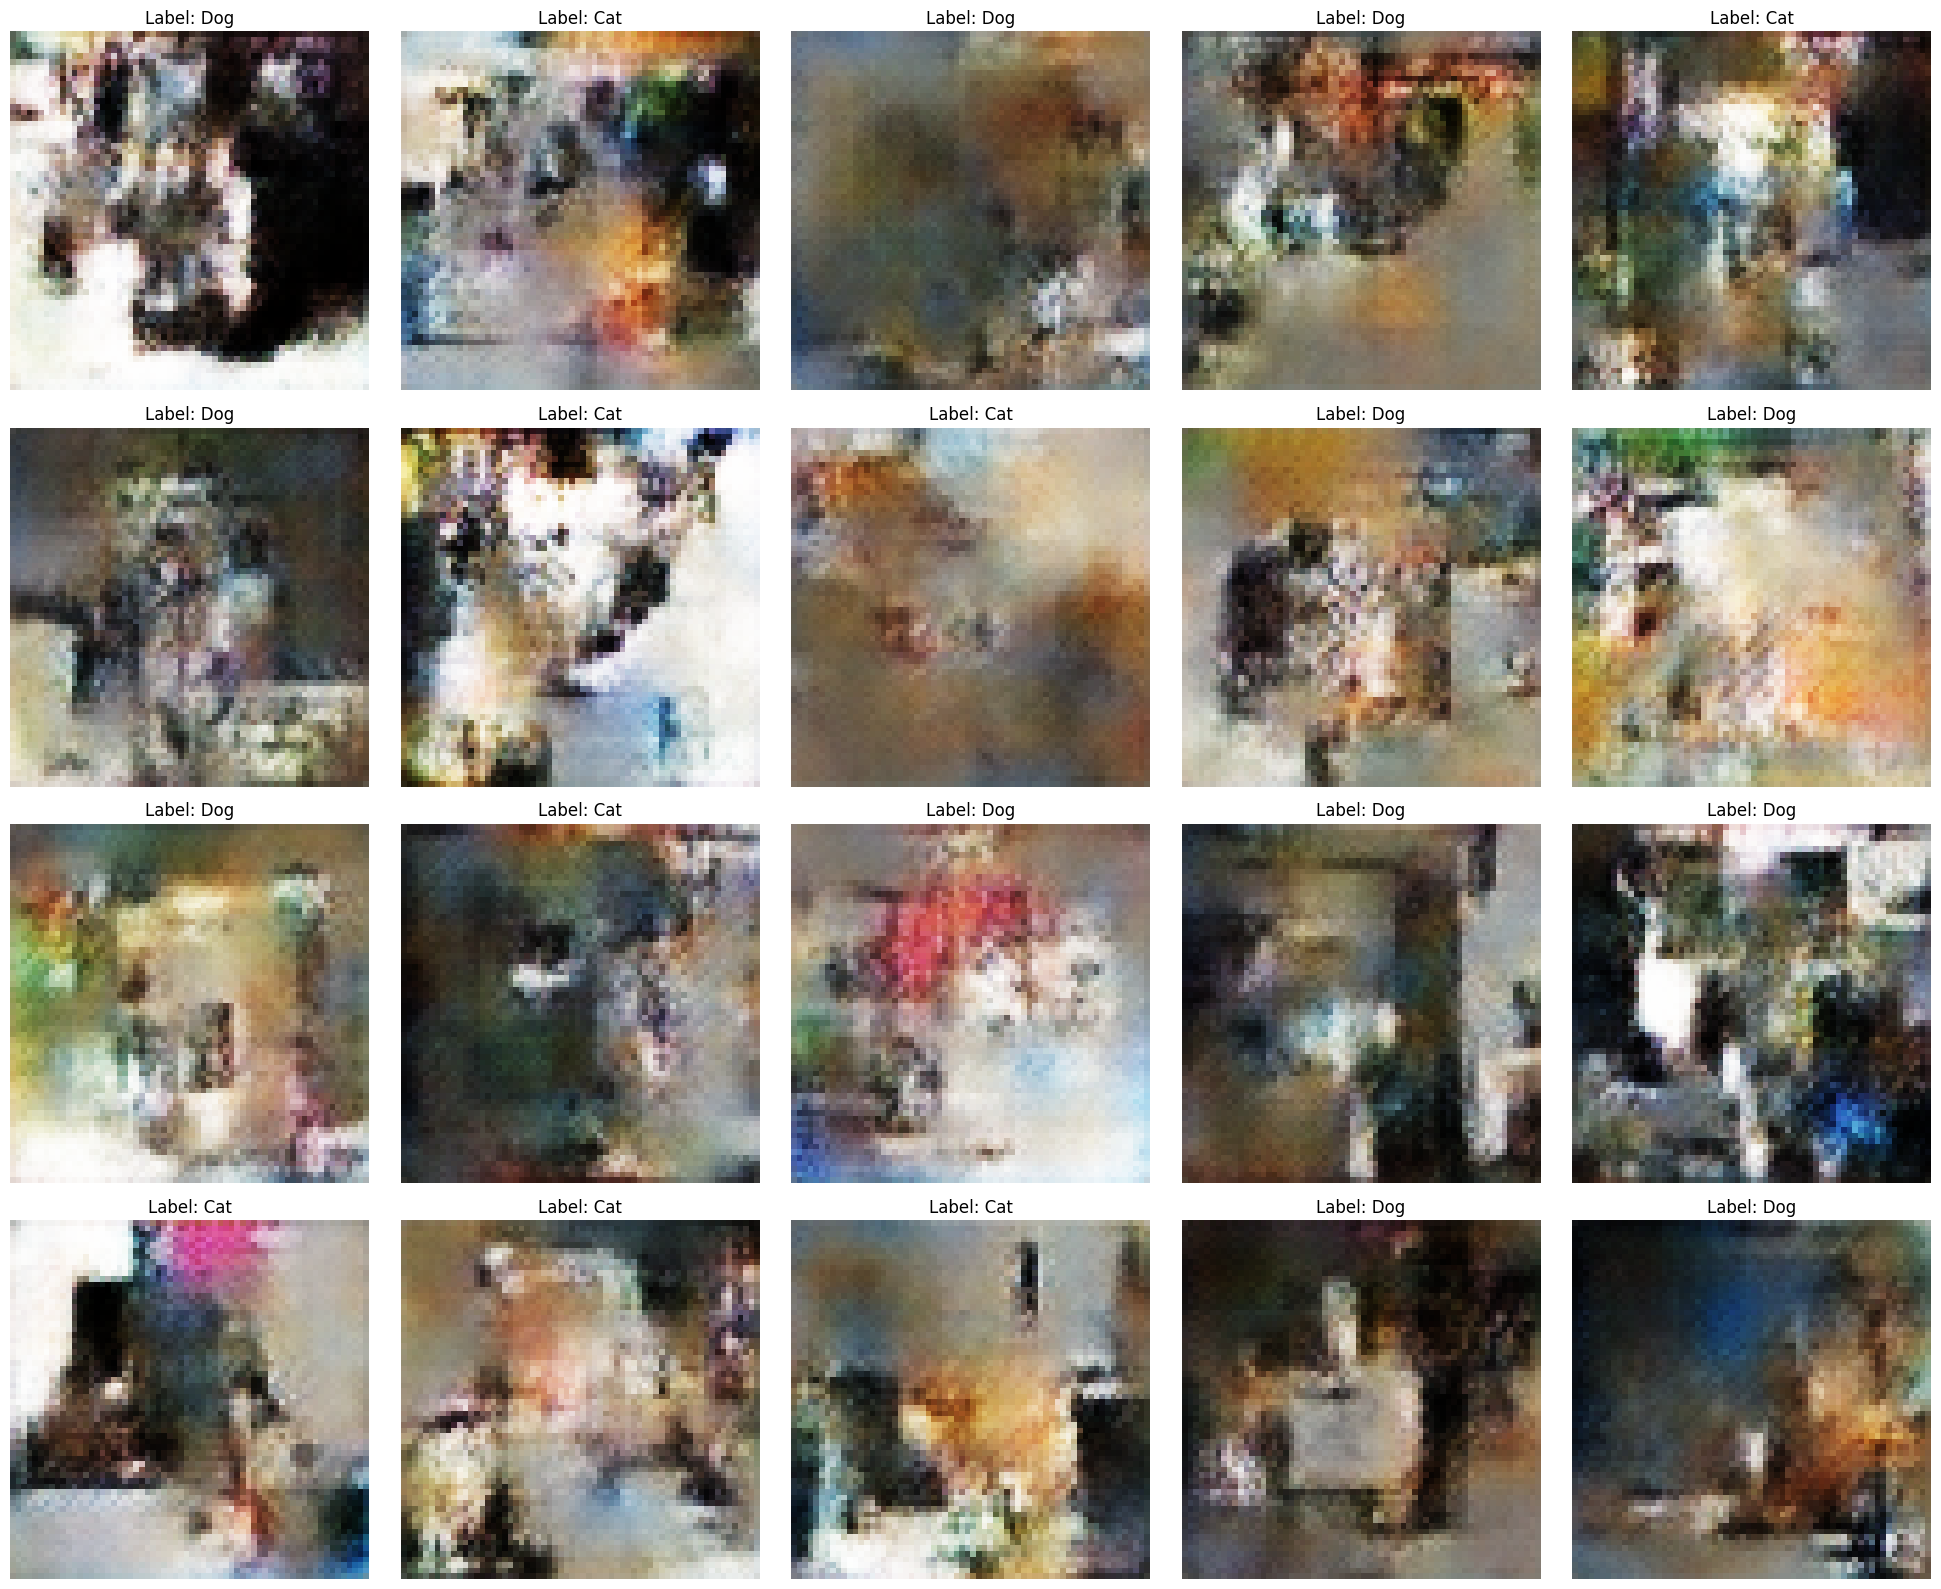

In [76]:
def generate_and_plot(num_examples=10):
    # Labels: 0 for Cat, 1 for Dog (randomly chosen for visualization)
    random_labels = tf.random.uniform((num_examples,), minval=0, maxval=2, dtype=tf.int32)
    noise = tf.random.normal([num_examples, LATENT_DIM])
    
    # Generate images
    generated_images = generator([noise, random_labels], training=False)
    
    # Rescale to [0, 1] for plotting
    generated_images = (generated_images + 1) / 2.0

    cols = 5  # Number of images per row
    rows = (num_examples + cols - 1) // cols  # Auto-calculate rows needed
    plt.figure(figsize=(cols * 4, rows * 4))  # 4 inches per image (width x height)    
    for i in range(num_examples):
        plt.subplot(rows, cols, i+1)
        plt.imshow(generated_images[i])
        label_text = "Dog" if random_labels[i] == 1 else "Cat"
        plt.title(f"Label: {label_text}")
        plt.axis("off")
        plt.tight_layout()
    plt.show()

# Visualize results
generate_and_plot(20)